Helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple

# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

# reconstruct the solution using the learned NN 'D_model' at the training points (x_train, t_train)
def recon_solution(x_train, t_train, D_model, u_true_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    u_sim = simulate_pde(x_train, u_true_IC, D_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

# Simulate the PDE u_t = (D(u) u_x)_x with Neumann BCs using method of lines and solve_ivp
def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: np.ndarray = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: str = None):
    """
    Simulate FKPP with BC: u_x=0 at boundaries (note: not no-flux BCs!).
    Inputs:
      x           : 1D grid (numpy array)
      IC          : initial condition (numpy array same length as x)
      D_callable  : function(u_array) -> D_array (same length as u)
      t_span      : (t0, tf)
      t_eval      : times to evaluate solution; default 201 points between t0 and tf
      integrator  : "RK45" or "BDF" etc; BDF recommended if stiff
      rtol, atol  : tolerances for solve_ivp
      save_path   : optional path to save final u as npy
    Returns:
      sol : the SciPy OdeResult-like object from solve_ivp (sol.y shape (N, len(t_eval)))
    """
    
    x = np.asarray(x)
    N = x.size
    dx = x[1] - x[0]
    assert IC.shape == x.shape, "IC must match x shape"
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def rhs(t, u_vec):
        u = np.asarray(u_vec)

        # Evaluate D at nodes
        Dn = D_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")

        # Build ghost-point extension for Neumann BCs: u_x = 0
        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]      # left ghost cell: u_{-1} = u_1
        u_ext[-1] = u[-2]    # right ghost cell: u_N = u_{N-2}

        # Extend D consistently
        Dn_ext = np.empty(N + 2, dtype=Dn.dtype)
        Dn_ext[1:-1] = Dn
        Dn_ext[0] = Dn[1]
        Dn_ext[-1] = Dn[-2]

        # D at interfaces
        D_half = 0.5 * (Dn_ext[:-1] + Dn_ext[1:])   # length N+1

        # Fluxes at interfaces
        flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx   # length N+1

        # Divergence at physical nodes
        diffusion_term = (flux[1:] - flux[:-1]) / dx

        return diffusion_term
        
    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    if not sol.success:
        print("Warning: solver reported failure:", sol.message)
    if save_path is not None:
        np.save(save_path, sol.y[:, -1])
        print(f"Saved final state to {save_path}")

    return sol.y.T


Plot formatting & setups

In [ ]:
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2

# epochs for training history
epoch_hist = np.arange(0, 4001, 1)

# time resolutions
Nt, t_end, t_min = 7, 18, 0.0
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx_long = 0.04
x_train = np.arange(x_min, x_max+dx_long, dx_long)
Nx = len(x_train)

# true solutions
D_true = 0.5 # true diffusivity
xx, tt = np.meshgrid(x_train, t_train)
u_true = 0.5 * np.cos(np.pi * xx / L) * np.exp(-tt * D_true * (np.pi**2) / (L**2)) + 0.5 # so that u in [0, 1]
u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)

# the variances we used 
variances = [0, 1e-3, 5e-3, 1e-2, 5e-2]
seed = 8

NumRep = 10

top_load_folder = '../ARCresults/Diffusion_linear/'  ### UPDATE WITH YOUR PATH OF THE DATA FOLDER
top_save_folder = '../Figures/Fig2/'


u_structs = [r'$(4, 32)$', r'$(6, 128)$']

### Plot: total validation loss over epochs

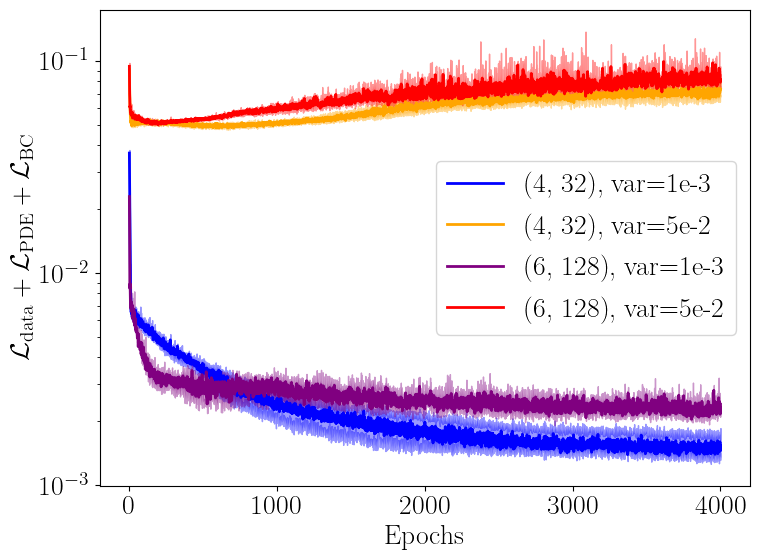

In [6]:
variances_ = [1e-3, 5e-2]
# blue for variance 1e-3 and (4, 32), orange for variance 1e-3 and (6, 128); 
# purple for variance 5e-2 and (4, 32), red for variance 5e-2 and (6, 128)
colors = [['blue', 'orange'], ['purple', 'red']] 
legends = [['(4, 32), var=1e-3', '(4, 32), var=5e-2'], ['(6, 128), var=1e-3', '(6, 128), var=5e-2']]
fig3, ax3 = plt.subplots(figsize=(8, 6))

for s, subfolder in enumerate(subfolders):
    for n, var in enumerate(variances_):
        # load loss_info
        val_pdeloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_pdeloss_S.npy', allow_pickle=True)
        val_uloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_uloss_S.npy', allow_pickle=True)
        val_BCloss_S = np.load(top_load_folder + subfolder + f'var{var}/val_BCloss_S.npy', allow_pickle=True)
        val_pdeloss_S, val_uloss_S, val_BCloss_S = np.asarray(val_pdeloss_S, dtype=float), np.asarray(val_uloss_S, dtype=float), np.asarray(val_BCloss_S, dtype=float)

        total_loss = val_uloss_S + val_BCloss_S + val_pdeloss_S
        median_total_loss = np.median(total_loss, axis=0)
        q1_total_loss = np.percentile(total_loss, 25, axis=0)
        q3_total_loss = np.percentile(total_loss, 75, axis=0)

        ax3.plot(epoch_hist, median_total_loss, label=legends[s][n], color=colors[s][n])
        ax3.fill_between(epoch_hist, q1_total_loss, q3_total_loss, color=colors[s][n], alpha=0.4)

ax3.set_yscale('log')
ax3.set_xlabel('Epochs')
ax3.set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
ax3.legend(loc='best')
fig3.tight_layout()

plt.show()
fig3.savefig(top_save_folder + 'valloss_history.svg', format='svg', bbox_inches='tight')

### Plot: BINNs learning outcome for variance = 1e-3 and u_struc = (4, 32)

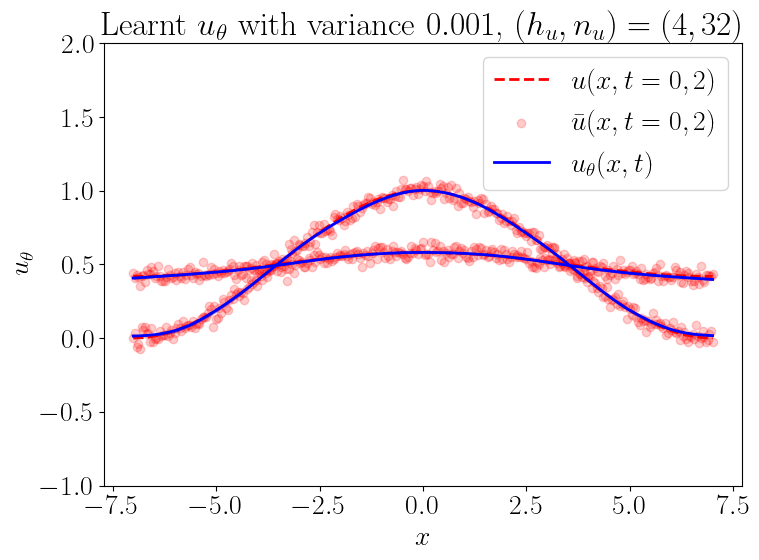

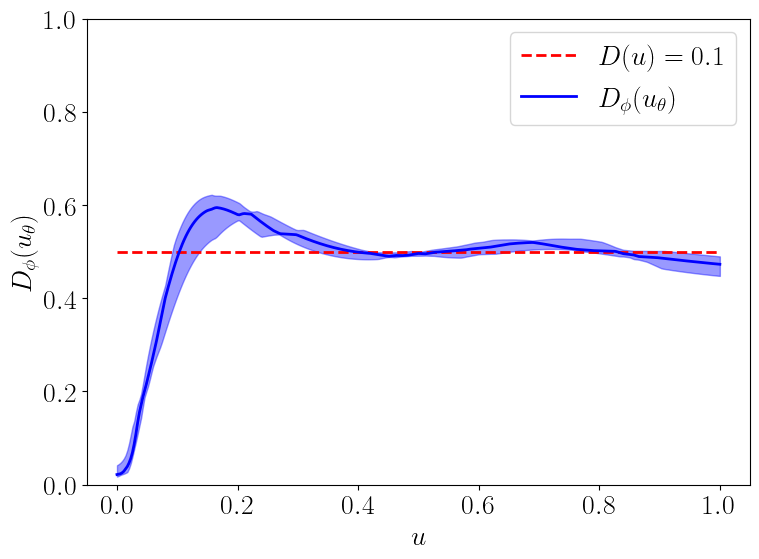

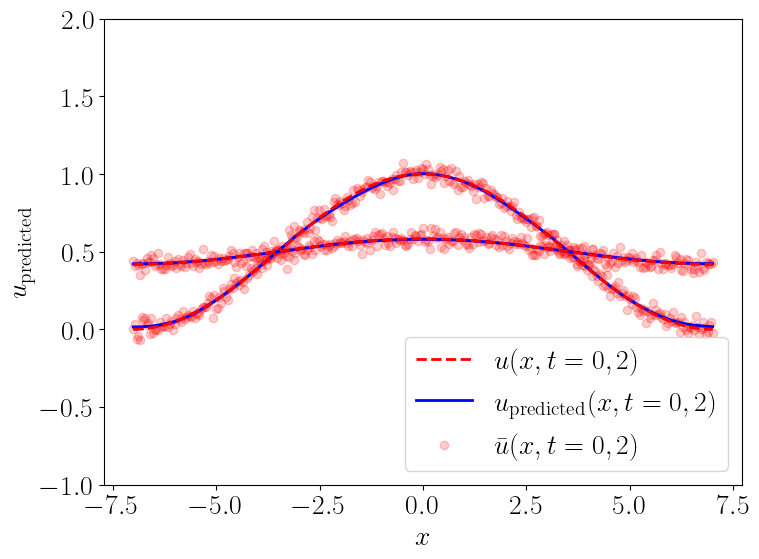

In [10]:
var = 1e-3

# load noisy training data: 
dataset = torch.load(top_load_folder + subfolders[0] + f'var{var}/full_dataset.pt', weights_only=False)  
x_data, u_data = dataset.tensors  # returns a tuple of tensors
x_data, u_data = x_data.numpy(), u_data.numpy()
x_data, t_data = x_data[:, 0], x_data[:, 1]
u_data = u_data.reshape(Nt, Nx)

u_learnt_all, D_learnt_all = [], []

for rep in range(NumRep):

    load_dir = top_load_folder + subfolders[0] + f'var{var}/Iter{rep}/'

    # load the leaernt u_NN
    u_learnt_np = np.load(load_dir + 'fullgrid_u_pred.npy')
    u_learnt_all.append(u_learnt_np)

    # load the learnt D_NN 
    test_D_pred_np = np.load(load_dir + 'fullgrid_D_pred.npy')
    D_learnt_all.append(test_D_pred_np)

u_learnt_all = np.array(u_learnt_all) # shape (NumRep, Nt, Nx)
u_learnt_median = np.median(u_learnt_all, axis=0)
u_learnt_25perc = np.percentile(u_learnt_all, 25, axis=0)
u_learnt_75perc = np.percentile(u_learnt_all, 75, axis=0)
D_learnt_all = np.array(D_learnt_all) # shape (NumRep, Nt, Nx)
D_learnt_median = np.median(D_learnt_all, axis=0)
D_learnt_25perc = np.percentile(D_learnt_all, 25, axis=0)
D_learnt_75perc = np.percentile(D_learnt_all, 75, axis=0)

# plot for u_NN
fig4, ax4 = plt.subplots(figsize=(8, 6))
t0, tfinal = 0, -1
# plot the noiseless and the noisy training data at t0 and tfinal
ax4.plot(x_train, u_true[t0, :], 'r--', label=r'$u(x, t=0, 2)$' if t0==0 else None)
ax4.scatter(x_train, u_data[t0, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t=0, 2)$' if t0 == 0 else "")
ax4.plot(x_train, u_true[tfinal, :], 'r--')
ax4.scatter(x_train, u_data[tfinal, :], color='red', alpha=0.2)

# plot the learnt solution at t0 and tfinal with median and 25-75 percentile shaded area
ax4.plot(x_train, u_learnt_median[t0, :], color='blue', label=r'$u_{\theta}(x, t)$' if t0==0 else None)
ax4.fill_between(x_train, u_learnt_25perc[t0, :], u_learnt_75perc[t0, :], color='blue', alpha=0.4)
ax4.plot(x_train, u_learnt_median[tfinal, :], color='blue')
ax4.fill_between(x_train, u_learnt_25perc[tfinal, :], u_learnt_75perc[tfinal, :], color='blue', alpha=0.4)

ax4.set_title(rf'Learnt $u_{{\theta}}$ with variance ${var}$, $(h_u, n_u)=(4, 32)$')
ax4.set_xlabel(r'$x$')
ax4.set_ylabel(r'$u_{\theta}$')
ax4.legend()
ax4.set_ylim([-1.0, 2.0])

fig4.tight_layout()
plt.show()
fig4.savefig(top_save_folder + f'uNN_var{var}.svg', format='svg', bbox_inches='tight')

# plot for D_NN
fig5, ax5 = plt.subplots(figsize=(8, 6))
ax5.plot(U_grid, D_true * np.ones_like(U_grid), 'r--', label=r'$D(u)=0.1$')
ax5.plot(U_grid, D_learnt_median.flatten(), color='blue', label=r'$D_{\phi}(u_{\theta})$')
ax5.fill_between(U_grid, D_learnt_25perc.flatten(), D_learnt_75perc.flatten(), color='blue', alpha=0.4)
ax5.set_xlabel(r'$u$')
ax5.set_ylabel(r'$D_{\phi}(u_{\theta})$')
ax5.legend()
ax5.set_ylim([0.0, 1.0])
fig5.tight_layout()
plt.show()
fig5.savefig(top_save_folder + f'DNN_var{var}.svg', format='svg', bbox_inches='tight')

# plot for the reconstructed solution u_reconstr 
u_pred_all = np.load(top_save_folder + 'u_pred_all.npy')
u_pred_ = u_pred_all[0][1]
u_pred_median = np.median(u_pred_, axis=0)
u_pred_25perc = np.percentile(u_pred_, 25, axis=0)
u_pred_75perc = np.percentile(u_pred_, 75, axis=0)

fig6, ax6 = plt.subplots(figsize=(8, 6))
ax6.set_xlabel(r'$x$')
ax6.set_ylabel(r'$u_{\mathrm{predicted}}$')

ax6.plot(x_train, u_true[t0, :], 'r--', label=r'$u(x, t=0, 2)$')
ax6.plot(x_train, u_pred_median[t0, :], color='blue', label=r'$u_{\mathrm{predicted}}(x, t=0, 2)$')
ax6.fill_between(x_train, u_pred_25perc[t0, :], u_pred_75perc[t0, :], color='blue', alpha=0.4)
ax6.plot(x_train, u_true[t0, :], 'r--')
ax6.scatter(x_train, u_data[t0, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t=0, 2)$')



ax6.plot(x_train, u_true[tfinal, :], 'r--')
ax6.plot(x_train, u_pred_median[tfinal, :], color='blue')
ax6.fill_between(x_train, u_pred_25perc[tfinal, :], u_pred_75perc[tfinal, :], color = 'blue', alpha=0.4)
ax6.plot(x_train, u_true[tfinal, :], 'r--')
ax6.scatter(x_train, u_data[tfinal, :], color='red', alpha=0.2)



ax6.set_ylim([-1.0, 2.0]) 
ax6.legend()
fig6.tight_layout()
plt.show()
fig6.savefig(top_save_folder + f'u_reconstr_var{var}.svg', format='svg', bbox_inches='tight')


